# 决策树：分而治之的规则树

**课程 0007 配套练习** · 内核：`deeplearning`

前置：课程 0005（偏差-方差）。前几课的「模型」都是函数（直线、概率分布）。这课换一种：**if-then 规则树**——每个结点一个「是/否」判断，叶子给出类别。它完全可解释，也是随机森林、梯度提升的积木。

> 读完后请回答：为什么「每次都选最优分裂」的贪心树，深了反而变差？

## 问题设定：两个咬合的月牙

逻辑回归在同心圆上切不开，因为模型只有直线。决策树对形状没有预设——它用一堆**轴对齐的矩形块**去逼近任意边界。我们用咬合月牙（make_moons）数据看看它行不行。

(140, 2)
train: (140, 2) test: (60, 2)


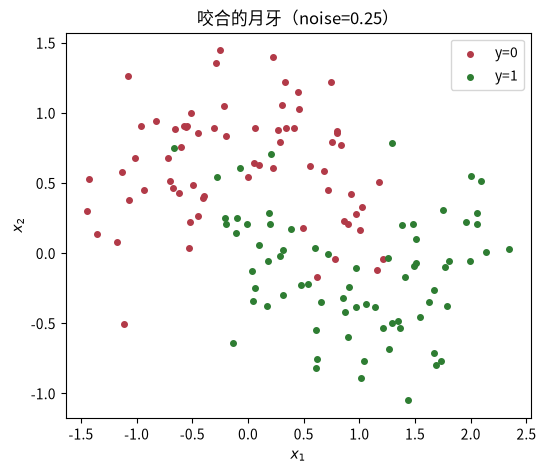

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 中文字体
import matplotlib as mpl
from matplotlib import font_manager
for name in ["Noto Sans CJK SC", "Noto Serif CJK SC", "WenQuanYi Zen Hei", "SimHei"]:
    if any(f.name == name for f in font_manager.fontManager.ttflist):
        mpl.rcParams["font.sans-serif"] = [name]
        break
mpl.rcParams["axes.unicode_minus"] = False

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=200, noise=0.25, random_state=0)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)
# print(Xtr.shape)
print("train:", Xtr.shape, "test:", Xte.shape)

plt.figure(figsize=(6, 5))
plt.scatter(Xtr[ytr == 0, 0], Xtr[ytr == 0, 1], c="#b23a48", s=16, label="y=0")
plt.scatter(Xtr[ytr == 1, 0], Xtr[ytr == 1, 1], c="#2e7d32", s=16, label="y=1")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.title("咬合的月牙（noise=0.25）")
plt.show()

## 三要素：规则集合、纯度、贪心递归

- **模型**：if-then 规则集合。从根到叶的每条路径是一条规则，规则互斥且完备。
- **策略**：每个结点选「让子结点最纯」的特征-阈值来分裂，用**信息增益**（或基尼不纯度）度量。
- **算法**：贪心递归——选最优分裂 → 分裂 → 递归，再用 `max_depth`/`min_samples_leaf` 预剪枝防过拟合。

先实现「纯度」的度量：熵。

In [ ]:
def entropy(y: np.ndarray) -> float:
    """熵 H(S) = -Σ p_i log2 p_i。越纯熵越低。"""
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)     # 得到每一类的概率
    return float(-(p * np.log2(p)).sum())   # 计算整个数据集的熵

print("全同类：", round(entropy(np.array([0, 0, 0])), 4))      # 应为 0
print("两类各半：", round(entropy(np.array([0, 0, 1, 1])), 4))  # 应为 1.0
print("3:1：", round(entropy(np.array([0, 0, 0, 1])), 4))       # 介于 0 和 1 之间

全同类： -0.0
两类各半： 1.0
3:1： 0.8113


## 信息增益：选特征的标准

按特征 A 分裂后，子结点熵的加权平均比原来小多少，就是**信息增益**：

$$\text{Gain}(S, A) = H(S) - \sum_v \frac{|S_v|}{|S|} H(S_v)$$

连续特征（像我们的 $x_1, x_2$）要把取值排序，在相邻值中点试所有切分点，选增益最大的。

In [ ]:
def best_split(X: np.ndarray, y: np.ndarray):
    """在 (特征, 阈值) 里找信息增益最大的切分。返回 (增益, 特征索引, 阈值)。"""
    n = len(y)
    H = entropy(y)      # 先得到根结点的熵
    best_gain, best_f, best_t = -np.inf, None, None
    for f in range(X.shape[1]):     # X.shape[1] 是特征数，X:[样本数, 特征数]
        vals = np.unique(X[:, f])   # vals 是特征 f 的所有不同取值
        if len(vals) < 2:
            continue
        thresholds = (vals[:-1] + vals[1:]) / 2          # 相邻值中点作为候选切分点
        for t in thresholds:
            left = y[X[:, f] <= t]
            right = y[X[:, f] > t]
            gain = H - (len(left) / n * entropy(left) + len(right) / n * entropy(right))
            if gain > best_gain:
                best_gain, best_f, best_t = gain, f, t
    return best_gain, best_f, best_t

gain, f, t = best_split(Xtr, ytr)
print(f"根结点最优分裂：特征 x_{f}，阈值 {t:.3f}，信息增益 {gain:.4f}")

根结点最优分裂：特征 x_1，阈值 0.319，信息增益 0.3632


## 手写递归决策树

「算法」就是递归：选最优分裂 → 左右递归 → 直到纯 / 深度上限 / 信息增益为 0。预测时从根走到叶子，叶子返回多数类。

In [ ]:
class Node:
    __slots__ = ("feature", "threshold", "left", "right", "pred")
    def __init__(self):
        self.feature = None      # 分裂特征索引
        self.threshold = None    # 分裂阈值
        self.left = None
        self.right = None
        self.pred = None         # 叶子：多数类

def fit_tree(X, y, depth=0, max_depth=6):
    node = Node()
    if depth >= max_depth or len(np.unique(y)) == 1:
        node.pred = int(np.bincount(y.astype(int)).argmax())        # bincount输入只能是非负整数，而unique速度略慢
        return node
    gain, f, t = best_split(X, y)
    if gain <= 0:
        node.pred = int(np.bincount(y.astype(int)).argmax())
        return node
    node.feature, node.threshold = f, t
    mask = X[:, f] <= t
    node.left = fit_tree(X[mask], y[mask], depth + 1, max_depth)    # 递归左子树
    node.right = fit_tree(X[~mask], y[~mask], depth + 1, max_depth) # 递归右子树
    return node

def predict_tree(node, X):
    out = np.empty(len(X), dtype=int)
    for i, x in enumerate(X):       # 对每个样本进行预测
        cur = node
        while cur.pred is None: # 往下递归直到叶子结点或者满足条件
            cur = cur.left if x[cur.feature] <= cur.threshold else cur.right   
        out[i] = cur.pred
    return out

tree = fit_tree(Xtr, ytr, max_depth=6)
print("train acc:", round(float(np.mean(predict_tree(tree, Xtr) == ytr)), 3))
print("test  acc:", round(float(np.mean(predict_tree(tree, Xte) == yte)), 3))

train acc: 0.971
test  acc: 0.933


## 轴对齐的矩形边界

每个结点只按**一个特征**切一刀，所以决策边界是平行于坐标轴的阶梯形，而不是斜线。

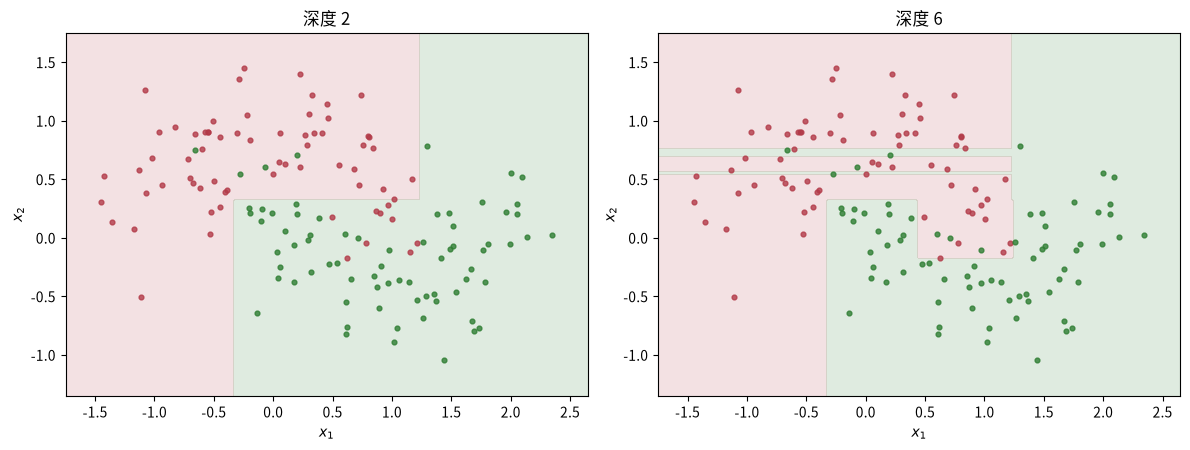

In [5]:
def plot_tree_boundary(X, y, ax, tree, title):
    x1 = np.linspace(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, 300)
    x2 = np.linspace(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, 300)
    xx, yy = np.meshgrid(x1, x2)
    Z = predict_tree(tree, np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=1, colors=["#b23a48", "#2e7d32"], alpha=0.15)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#b23a48", s=12, alpha=0.8)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#2e7d32", s=12, alpha=0.8)
    ax.set_title(title); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
plot_tree_boundary(Xtr, ytr, axes[0], fit_tree(Xtr, ytr, max_depth=2), "深度 2")
plot_tree_boundary(Xtr, ytr, axes[1], fit_tree(Xtr, ytr, max_depth=6), "深度 6")
plt.tight_layout(); plt.show()

## 深度 vs 过拟合：又一次偏差-方差

深度小 → 规则太粗（高偏差）；深度大 → 把训练集「背下来」（高方差）。最佳深度在中间。这就是 0005 学过的偏差-方差权衡在树上的翻版。

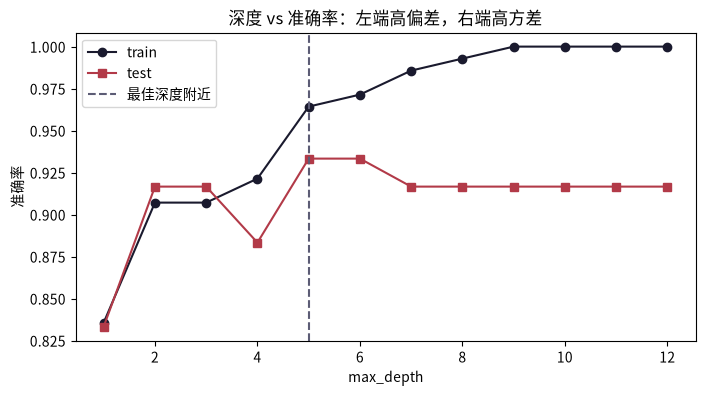

In [12]:
depths = range(1, 13)
tr_acc, te_acc = [], []
for d in depths:
    t = fit_tree(Xtr, ytr, max_depth=d)
    tr_acc.append(np.mean(predict_tree(t, Xtr) == ytr))
    te_acc.append(np.mean(predict_tree(t, Xte) == yte))

plt.figure(figsize=(8, 4))
plt.plot(list(depths), tr_acc, "o-", label="train", color="#1a1a2e")
plt.plot(list(depths), te_acc, "s-", label="test", color="#b23a48")
plt.axvline(5, ls="--", color="#5c5c75", label="最佳深度附近")
plt.xlabel("max_depth"); plt.ylabel("准确率"); plt.legend()
plt.title("深度 vs 准确率：左端高偏差，右端高方差")
plt.show()

## sklearn 版：一行搞定 + 特征重要性

scikit-learn 的 `DecisionTreeClassifier` 默认用**基尼不纯度**（和熵几乎等价，但不用算 log）。它还给你树结构和特征重要性（每个特征参与分裂带来的纯度提升占比）。

sklearn test acc: 0.933
特征重要性 x1, x2： [0.374 0.626]


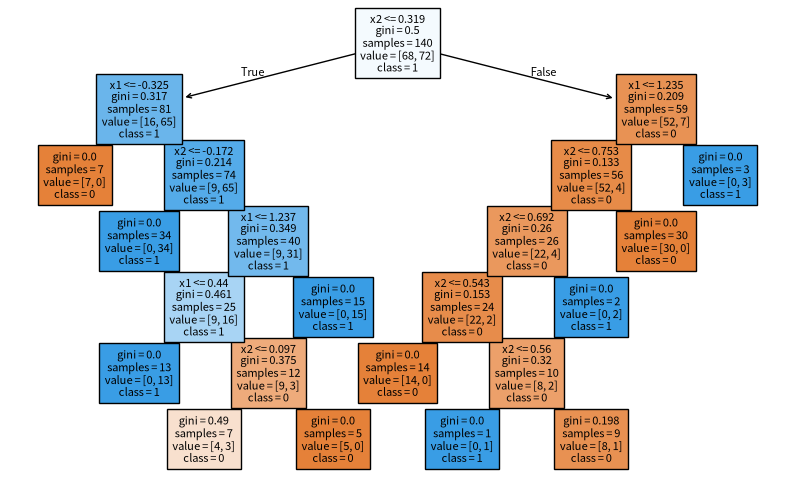

In [7]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

clf = DecisionTreeClassifier(max_depth=6, random_state=0).fit(Xtr, ytr)
print("sklearn test acc:", round(float(clf.score(Xte, yte)), 3))
print("特征重要性 x1, x2：", np.round(clf.feature_importances_, 3))

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
plot_tree(clf, ax=ax, filled=True, feature_names=["x1", "x2"], class_names=["0", "1"], fontsize=8)
plt.show()

## 练习（S 理解 / M 动手 / H 挑战）

**S1.** 为什么决策树的边界总是平行于坐标轴的直线段，不能是斜线？斜边界要怎样才表达得出来？

**S2.** 熵的极端值：全同类的熵是 0；如果某结点里两类各占一半，熵是 1。试想一个类别占比为 $p$ 的结点，画出 H(p) 随 p 的曲线（0 到 1），解释为什么「越接近 0.5 越难决策」。

**M1.** 把 sklearn 的 `DecisionTreeClassifier` 换成 `criterion="entropy"`，对比手写版（同样是信息增益）在训练集上的准确率，应该几乎一致。

**M2.** 把 `max_depth` 从 1 扫到 15，打印 train/test 准确率；找出测试集上的最佳深度，并说明深度过大时你在观察的是「偏差」还是「方差」。

**H1.** 实现 `gini(y)`（基尼不纯度 = $1 - \sum p_i^2$），并把 `best_split` 改成基尼版；在同一数据上对比它和熵版选出的根结点分裂，解释为什么二者通常接近。

**H2.** 给训练数据加一列「纯随机噪声」特征（如 `np.random.default_rng(0).uniform(0, 1, n)`），看 sklearn 树的特征重要性——噪声列会不会也拿高重要性？这说明用特征重要性选特征时要小心什么？

In [ ]:
# pass  # 练习区（S1/S2）
# 多棵决策树集成（随机森林、梯度提升树），多棵轴平行边界叠加，可以近似拟合斜线、非线性边界。
# 熵越大系统越不确定，信息增益越大，说明该特征对分类的贡献越大。

0.9642857142857143
0.9333333333333333


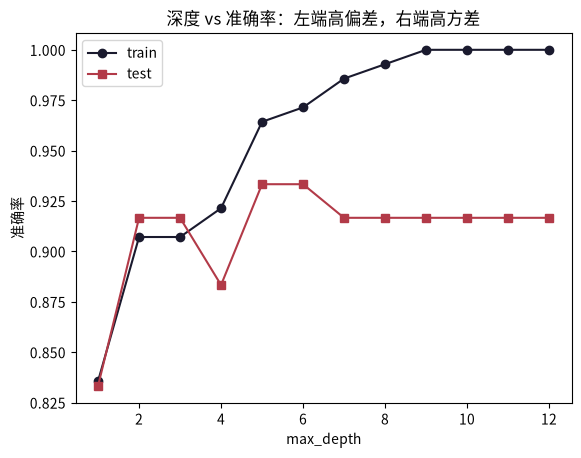

In [15]:
# pass  # 练习区（M1/M2）
from sklearn.tree import DecisionTreeClassifier
# criterion="entropy"就是用信息增益做分裂，和 ID3 标准一致。
model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)
model.fit(Xtr, ytr)
print(model.score(Xtr, ytr))
print(model.score(Xte, yte))

# max_depth很小：训练集、测试集准确率都低 → 高偏差（欠拟合），模型太简单。
# 随着深度增加：训练集准确率持续上升；测试集率先上升，到达一个最高点后开始下降。
# max_depth过大：训练集准确率几乎 100%，测试集准确率明显下滑 → 过拟合。

train_acc, test_acc = [], []
for d in range(1, 13):
    model = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=0)
    model.fit(Xtr, ytr)
    # print(f"max_depth={d}: train acc={model.score(Xtr, ytr):.3f}, test acc={model.score(Xte, yte):.3f}
    #")
    train_acc.append(model.score(Xtr, ytr))
    test_acc.append(model.score(Xte, yte))
    
plt.plot(range(1, 13), train_acc, "o-", label="train", color="#1a1a2e")
plt.plot(range(1, 13), test_acc, "s-", label="test", color="#b23a48")
plt.xlabel("max_depth"); plt.ylabel("准确率"); plt.legend()
plt.title("深度 vs 准确率：左端高偏差，右端高方差")
plt.show()

In [ ]:
# pass  # 练习区（H1/H2）
def gini(y: np.ndarray) -> float:
    """基尼指数 G(S) = 1 - Σ p_i^2。越纯基尼越低。"""
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)     # 得到每一类的概率
    return float(1 - (p ** 2).sum())   # 计算整个数据集的基尼指数

# 香农熵和基尼不纯度两者变化趋势高度同步，都是衡量集合混杂程度。

# 随机噪声有可能得到较高特征重要性；特征重要性不可完全信赖，不能单独作为筛选特征唯一依据，需要交叉验证佐证。